In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("winequality-white.csv", sep=";")

print("Original Dataset Shape:", df.shape)

duplicate_count = df.duplicated().sum()

missing_rows = df.isnull().any(axis=1).sum()

print("Duplicate rows:", duplicate_count)
print("Rows containing missing values:", missing_rows)

df = df.drop_duplicates()

df = df.dropna()

print("Final Dataset Shape:", df.shape)

Original Dataset Shape: (4898, 12)
Duplicate rows: 937
Rows containing missing values: 0
Final Dataset Shape: (3961, 12)


In [3]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "density",
    "chlorides",
    "sulphates",
    "citric acid"
]

X = df[selected_features]
y = df["quality"]

print("\nSelected Features:")
print(selected_features)

print("\nTarget:")
print("quality")

print("\nFinal X Shape:", X.shape)
print("Final y Shape:", y.shape)


Selected Features:
['alcohol', 'volatile acidity', 'density', 'chlorides', 'sulphates', 'citric acid']

Target:
quality

Final X Shape: (3961, 6)
Final y Shape: (3961,)


In [4]:
def create_model():
    return RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

In [5]:
def calculate_metrics(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [6]:
start_time = time.perf_counter()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = create_model()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

single_train_accuracy = accuracy_score(y_train, y_train_pred)

single_results = calculate_metrics(y_test, y_test_pred)

single_time = time.perf_counter() - start_time

print("\n================================================")
print("1. SINGLE TRAIN-TEST SPLIT")
print("================================================")

for metric, value in single_results.items():
    print(f"{metric}: {value:.4f}")

print(f"Train Accuracy: {single_train_accuracy:.4f}")
print(f"Test Accuracy : {single_results['Accuracy']:.4f}")

print(
    f"Generalization Gap: "
    f"{single_train_accuracy - single_results['Accuracy']:.4f}"
)

print(f"Computational Time: {single_time:.4f} seconds")


1. SINGLE TRAIN-TEST SPLIT
Accuracy: 0.5233
Precision: 0.4995
Recall: 0.5233
F1 Score: 0.4941
Train Accuracy: 1.0000
Test Accuracy : 0.5233
Generalization Gap: 0.4767
Computational Time: 1.5475 seconds


In [9]:
N_SPLITS = 30

random_results = []

start_time = time.perf_counter()

for random_state in range(1, N_SPLITS + 1):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=random_state,
        stratify=y
    )

    model = create_model()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = calculate_metrics(y_test, y_test_pred)

    train_accuracy = accuracy_score(y_train, y_train_pred)

    random_results.append({
        "Split": random_state,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1 Score": metrics["F1 Score"],
        "Train Accuracy": train_accuracy,
        "Generalization Gap":
            train_accuracy - metrics["Accuracy"]
    })

random_time = time.perf_counter() - start_time

random_df = pd.DataFrame(random_results)

print("\n================================================")
print("2. 30 REPEATED RANDOM 80/20 SPLITS")
print("================================================")

print("\nFirst few results:")
print(random_df.head())

print("\n--- Mean ---")
print(random_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].mean())

print("\n--- Standard Deviation ---")
print(random_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].std())

print("\n--- Minimum ---")
print(random_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].min())

print("\n--- Maximum ---")
print(random_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].max())

print("\n--- Range ---")
print(
    random_df[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ].max()
    -
    random_df[
        ["Accuracy", "Precision", "Recall", "F1 Score"
    ]].min()
)

print(
    f"\nAverage Generalization Gap: "
    f"{random_df['Generalization Gap'].mean():.4f}"
)

print(f"Total Computational Time: {random_time:.4f} seconds")
print(
    f"Average Time per Split: "
    f"{random_time / N_SPLITS:.4f} seconds"
)


2. 30 REPEATED RANDOM 80/20 SPLITS

First few results:
   Split  Accuracy  Precision    Recall  F1 Score  Train Accuracy  \
0      1  0.553594   0.544007  0.553594  0.526952             1.0   
1      2  0.534678   0.512737  0.534678  0.509971             1.0   
2      3  0.542245   0.522648  0.542245  0.515607             1.0   
3      4  0.532156   0.498734  0.532156  0.505683             1.0   
4      5  0.522068   0.501969  0.522068  0.500142             1.0   

   Generalization Gap  
0            0.446406  
1            0.465322  
2            0.457755  
3            0.467844  
4            0.477932  

--- Mean ---
Accuracy     0.529634
Precision    0.513535
Recall       0.529634
F1 Score     0.505411
dtype: float64

--- Standard Deviation ---
Accuracy     0.014620
Precision    0.021494
Recall       0.014620
F1 Score     0.013678
dtype: float64

--- Minimum ---
Accuracy     0.503153
Precision    0.483894
Recall       0.503153
F1 Score     0.479507
dtype: float64

--- Maximum ---


In [10]:
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

start_time = time.perf_counter()

for fold, (train_index, test_index) in enumerate(
    kf.split(X, y),
    start=1
):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = create_model()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = calculate_metrics(y_test, y_test_pred)

    train_accuracy = accuracy_score(y_train, y_train_pred)

    cv_results.append({
        "Fold": fold,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1 Score": metrics["F1 Score"],
        "Train Accuracy": train_accuracy,
        "Generalization Gap":
            train_accuracy - metrics["Accuracy"]
    })

cv_time = time.perf_counter() - start_time

cv_df = pd.DataFrame(cv_results)

print("\n================================================")
print("3. 5-FOLD CROSS-VALIDATION")
print("================================================")

print("\nResults for each fold:")
print(cv_df)

print("\n--- Mean ---")
print(cv_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].mean())

print("\n--- Standard Deviation ---")
print(cv_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].std())

print("\n--- Minimum ---")
print(cv_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].min())

print("\n--- Maximum ---")
print(cv_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].max())

print("\n--- Range ---")
print(
    cv_df[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ].max()
    -
    cv_df[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ].min()
)

print(
    f"\nAverage Generalization Gap: "
    f"{cv_df['Generalization Gap'].mean():.4f}"
)

print(f"Total Computational Time: {cv_time:.4f} seconds")
print(
    f"Average Time per Fold: "
    f"{cv_time / 5:.4f} seconds"
)


3. 5-FOLD CROSS-VALIDATION

Results for each fold:
   Fold  Accuracy  Precision    Recall  F1 Score  Train Accuracy  \
0     1  0.529634   0.505950  0.529634  0.501259             1.0   
1     2  0.526515   0.506329  0.526515  0.505625             1.0   
2     3  0.530303   0.521316  0.530303  0.505627             1.0   
3     4  0.525253   0.494973  0.525253  0.496665             1.0   
4     5  0.542929   0.524591  0.542929  0.516249             1.0   

   Generalization Gap  
0            0.470366  
1            0.473485  
2            0.469697  
3            0.474747  
4            0.457071  

--- Mean ---
Accuracy     0.530927
Precision    0.510632
Recall       0.530927
F1 Score     0.505085
dtype: float64

--- Standard Deviation ---
Accuracy     0.007032
Precision    0.012193
Recall       0.007032
F1 Score     0.007259
dtype: float64

--- Minimum ---
Accuracy     0.525253
Precision    0.494973
Recall       0.525253
F1 Score     0.496665
dtype: float64

--- Maximum ---
Accuracy  

In [11]:
comparison = pd.DataFrame({
    "Method": [
        "Single 80/20 Split",
        "30 Random 80/20 Splits",
        "5-Fold Cross-Validation"
    ],

    "Mean Accuracy": [
        single_results["Accuracy"],
        random_df["Accuracy"].mean(),
        cv_df["Accuracy"].mean()
    ],

    "Std Accuracy": [
        np.nan,
        random_df["Accuracy"].std(),
        cv_df["Accuracy"].std()
    ],

    "Mean Precision": [
        single_results["Precision"],
        random_df["Precision"].mean(),
        cv_df["Precision"].mean()
    ],

    "Mean Recall": [
        single_results["Recall"],
        random_df["Recall"].mean(),
        cv_df["Recall"].mean()
    ],

    "Mean F1 Score": [
        single_results["F1 Score"],
        random_df["F1 Score"].mean(),
        cv_df["F1 Score"].mean()
    ],

    "Computational Time (s)": [
        single_time,
        random_time,
        cv_time
    ]
})

print("\n================================================")
print("FINAL COMPARISON")
print("================================================")

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


FINAL COMPARISON
                 Method  Mean Accuracy  Std Accuracy  Mean Precision  Mean Recall  Mean F1 Score  Computational Time (s)
     Single 80/20 Split         0.5233           NaN          0.4995       0.5233         0.4941                  1.5475
 30 Random 80/20 Splits         0.5296        0.0146          0.5135       0.5296         0.5054                 35.4666
5-Fold Cross-Validation         0.5309        0.0070          0.5106       0.5309         0.5051                 10.6673


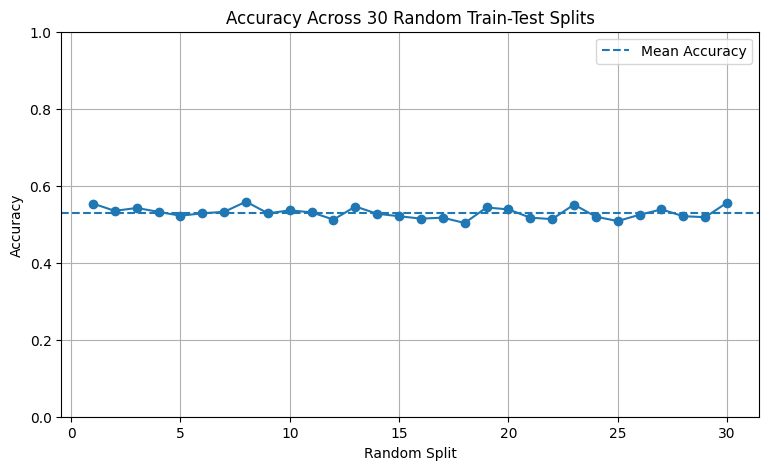

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    random_df["Split"],
    random_df["Accuracy"],
    marker="o"
)

plt.axhline(
    random_df["Accuracy"].mean(),
    linestyle="--",
    label="Mean Accuracy"
)

plt.title("Accuracy Across 30 Random Train-Test Splits")
plt.xlabel("Random Split")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

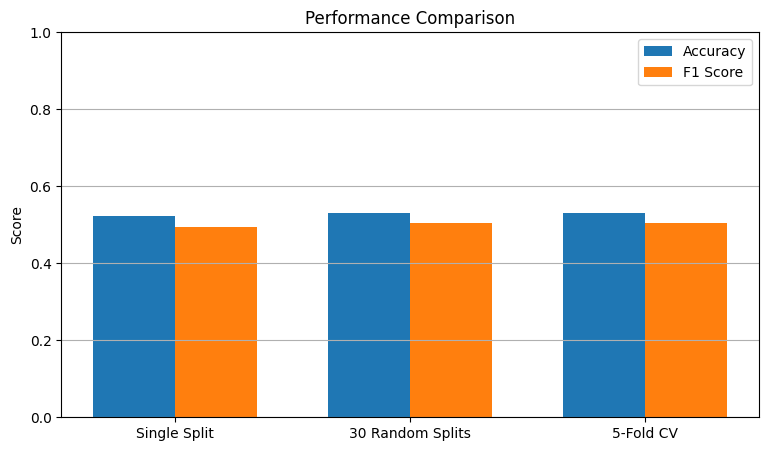

In [13]:
methods = [
    "Single Split",
    "30 Random Splits",
    "5-Fold CV"
]

mean_accuracy = [
    single_results["Accuracy"],
    random_df["Accuracy"].mean(),
    cv_df["Accuracy"].mean()
]

mean_f1 = [
    single_results["F1 Score"],
    random_df["F1 Score"].mean(),
    cv_df["F1 Score"].mean()
]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    mean_accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    mean_f1,
    width,
    label="F1 Score"
)

plt.xticks(x, methods)
plt.ylabel("Score")
plt.title("Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")
plt.show()

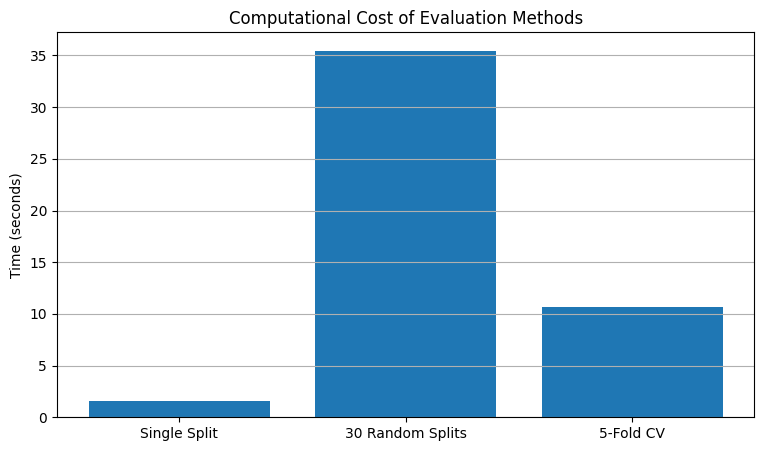

In [14]:
times = [
    single_time,
    random_time,
    cv_time
]

plt.figure(figsize=(9, 5))

plt.bar(
    methods,
    times
)

plt.ylabel("Time (seconds)")
plt.title("Computational Cost of Evaluation Methods")
plt.grid(axis="y")
plt.show()

In [15]:
print("\n================================================")
print("GENERALIZATION SUMMARY")
print("================================================")

print(
    f"Single Split Test Accuracy       : "
    f"{single_results['Accuracy']:.4f}"
)

print(
    f"Repeated Split Mean Test Accuracy: "
    f"{random_df['Accuracy'].mean():.4f}"
)

print(
    f"5-Fold CV Mean Test Accuracy     : "
    f"{cv_df['Accuracy'].mean():.4f}"
)



GENERALIZATION SUMMARY
Single Split Test Accuracy       : 0.5233
Repeated Split Mean Test Accuracy: 0.5296
5-Fold CV Mean Test Accuracy     : 0.5309
